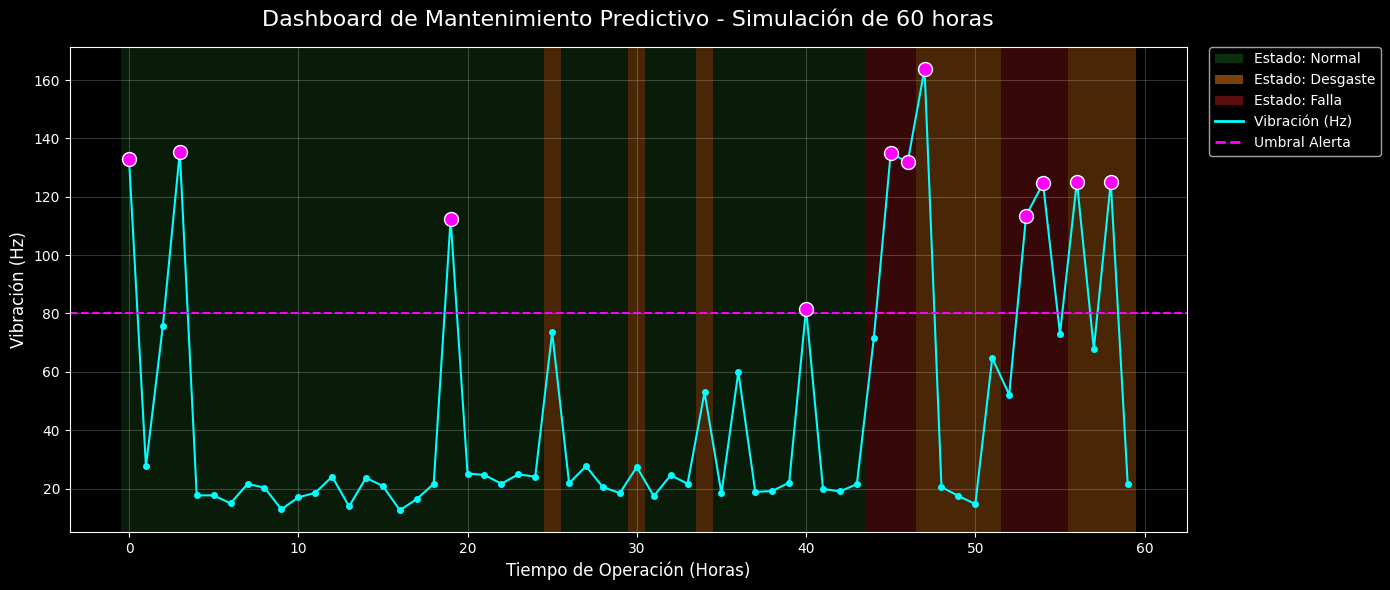


🏭 REPORTE DE SALUD DE LA MAQUINARIA
Estado Actual Inferido:  🔴 EN FALLA (Crítico)
Tendencia Degradación:   +11.67% (Últimas 5h)

📊 MÉTRICAS DE MANTENIMIENTO:
- Tiempo Medio Entre Fallas (MTBF): ~1.8 horas
- Vida Útil Restante Estimada (RUL): 0.0 horas
- Última vibración registrada:       21.73 Hz
- Total alertas disparadas:          11

💰 ANÁLISIS DE COSTOS:
- Costo Mantenimiento Preventivo:    $1500
- Costo Estimado de Falla Inminente: $8500
- Riesgo Financiero Actual:          $8500.00

⚙️ RECOMENDACIONES DEL SISTEMA:
>> PELIGRO: El equipo ha fallado o está en proceso inminente de falla.
>> Acción: Detener equipo y ejecutar mantenimiento correctivo inmediatamente.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

class HMM_PredictiveMaintenance:
    def __init__(self):
        # Definición de estados y observaciones
        self.states = ['Estado Normal', 'Estado de Desgaste', 'Estado de Falla']
        self.observations = ['Vibración Baja', 'Vibración Media', 'Vibración Alta']

        # Parámetros del modelo según especificaciones
        self.pi = np.array([0.8, 0.15, 0.05]) # Distribución inicial

        # Matriz de Transición (A)
        self.A = np.array([
            [0.85, 0.13, 0.02], # Normal a ...
            [0.30, 0.50, 0.20], # Desgaste a ...
            [0.05, 0.15, 0.80]  # Falla a ...
        ])

        # Matriz de Emisión (B)
        self.B = np.array([
            [0.80, 0.15, 0.05], # Normal emite ...
            [0.30, 0.50, 0.20], # Desgaste emite ...
            [0.10, 0.30, 0.60]  # Falla emite ...
        ])

        # Parámetros para simulación continua (Hz)
        # Media y desviación estándar para cada tipo de vibración
        self.vibration_params = {
            0: {'mean': 20.0, 'std': 5.0},  # Baja
            1: {'mean': 60.0, 'std': 10.0}, # Media
            2: {'mean': 120.0, 'std': 20.0} # Alta
        }

    def simulate(self, steps=60):
        """Simula los estados ocultos y las observaciones durante N horas."""
        true_states = []
        obs_discrete = []
        obs_continuous = []

        # Estado inicial
        current_state = np.random.choice(3, p=self.pi)

        for _ in range(steps):
            true_states.append(current_state)

            # Generar observación discreta
            current_obs = np.random.choice(3, p=self.B[current_state])
            obs_discrete.append(current_obs)

            # Generar valor continuo de vibración (Hz)
            hz = np.random.normal(
                loc=self.vibration_params[current_obs]['mean'],
                scale=self.vibration_params[current_obs]['std']
            )
            obs_continuous.append(max(0, hz)) # Evitar Hz negativos

            # Transición al siguiente estado
            current_state = np.random.choice(3, p=self.A[current_state])

        return np.array(true_states), np.array(obs_discrete), np.array(obs_continuous)

    def calculate_rul(self, current_state, n_simulations=1000):
        """Calcula el Remaining Useful Life (RUL) simulando hasta la falla."""
        if current_state == 2: return 0.0

        times_to_failure = []
        for _ in range(n_simulations):
            state = current_state
            steps = 0
            # Simular hasta llegar a Falla (estado 2)
            while state != 2 and steps < 500: # Límite de seguridad
                state = np.random.choice(3, p=self.A[state])
                steps += 1
            times_to_failure.append(steps)

        return np.mean(times_to_failure)

    def viterbi_inference(self, obs_seq):
        """Infere el estado oculto más probable basado en observaciones."""
        T = len(obs_seq)
        N = len(self.states)

        dp = np.zeros((N, T))
        path = np.zeros((N, T), dtype=int)

        dp[:, 0] = self.pi * self.B[:, obs_seq[0]]

        for t in range(1, T):
            for j in range(N):
                prob = dp[:, t-1] * self.A[:, j] * self.B[j, obs_seq[t]]
                dp[j, t] = np.max(prob)
                path[j, t] = np.argmax(prob)

        # Backtracking
        inferred_states = np.zeros(T, dtype=int)
        inferred_states[-1] = np.argmax(dp[:, -1])

        for t in range(T-2, -1, -1):
            inferred_states[t] = path[inferred_states[t+1], t+1]

        return inferred_states

    def generate_dashboard_and_report(self, steps=60):
        # 1. Ejecutar Simulación
        true_states, obs_discrete, obs_continuous = self.simulate(steps)
        inferred_states = self.viterbi_inference(obs_discrete)

        # 2. Calcular Métricas
        falla_indices = np.where(true_states == 2)[0]
        if len(falla_indices) > 1:
            mtbf = np.mean(np.diff(falla_indices))
        else:
            mtbf = steps # Aproximación si no hay múltiples fallas

        current_state = inferred_states[-1]
        rul = self.calculate_rul(current_state)

        # Costos hipotéticos
        cost_preventive = 1500
        cost_reactive = 8500
        cost_risk = (1 / max(1, rul)) * cost_reactive if current_state != 2 else cost_reactive

        # 3. Visualización - Dashboard Industrial
        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(14, 6))

        time = np.arange(steps)

        # Zonas de color según el estado REAL para ver cómo la vibración refleja el estado
        colors = {0: '#1b5e20', 1: '#f57f17', 2: '#b71c1c'} # Verde oscuro, Amarillo, Rojo
        for t in range(steps):
            ax.axvspan(t-0.5, t+0.5, color=colors[true_states[t]], alpha=0.3, lw=0)

        # Línea de vibración continua
        ax.plot(time, obs_continuous, color='cyan', marker='o', markersize=4, linestyle='-', linewidth=1.5, label='Vibración Medida (Hz)')

        # Alertas Tempranas (Vibración > 80 Hz)
        alert_threshold = 80
        ax.axhline(alert_threshold, color='magenta', linestyle='--', linewidth=1.5, label='Umbral de Alerta Temprana')
        alerts = np.where(obs_continuous > alert_threshold)[0]
        ax.scatter(alerts, obs_continuous[alerts], color='magenta', s=100, zorder=5, edgecolors='white', label='Alerta Disparada')

        # Configuración del gráfico
        ax.set_title(f'Dashboard de Mantenimiento Predictivo - Simulación de {steps} horas', fontsize=16, pad=15)
        ax.set_xlabel('Tiempo de Operación (Horas)', fontsize=12)
        ax.set_ylabel('Vibración (Hz)', fontsize=12)
        ax.grid(True, alpha=0.2)

        # Leyenda personalizada
        legend_elements = [
            Patch(facecolor='#1b5e20', alpha=0.5, label='Estado: Normal'),
            Patch(facecolor='#f57f17', alpha=0.5, label='Estado: Desgaste'),
            Patch(facecolor='#b71c1c', alpha=0.5, label='Estado: Falla'),
            plt.Line2D([0], [0], color='cyan', lw=2, label='Vibración (Hz)'),
            plt.Line2D([0], [0], color='magenta', linestyle='--', lw=2, label='Umbral Alerta'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
        plt.tight_layout()
        plt.show()

        # 4. Generar Reporte de Salud
        print("\n" + "="*50)
        print("🏭 REPORTE DE SALUD DE LA MAQUINARIA")
        print("="*50)

        # Semáforo de estado actual (basado en el estado inferido)
        semaforo = {0: '🟢 NORMAL', 1: '🟡 EN DESGASTE (Alerta)', 2: '🔴 EN FALLA (Crítico)'}
        print(f"Estado Actual Inferido:  {semaforo[current_state]}")

        # Análisis de tendencia simple (últimas 5 horas vs 5 horas anteriores)
        if steps >= 10:
            trend_recent = np.mean(obs_continuous[-5:])
            trend_past = np.mean(obs_continuous[-10:-5])
            degradacion = ((trend_recent - trend_past) / trend_past) * 100
            print(f"Tendencia Degradación:   {degradacion:+.2f}% (Últimas 5h)")

        print(f"\n📊 MÉTRICAS DE MANTENIMIENTO:")
        print(f"- Tiempo Medio Entre Fallas (MTBF): ~{mtbf:.1f} horas")
        print(f"- Vida Útil Restante Estimada (RUL): {rul:.1f} horas")
        print(f"- Última vibración registrada:       {obs_continuous[-1]:.2f} Hz")
        print(f"- Total alertas disparadas:          {len(alerts)}")

        print(f"\n💰 ANÁLISIS DE COSTOS:")
        print(f"- Costo Mantenimiento Preventivo:    ${cost_preventive}")
        print(f"- Costo Estimado de Falla Inminente: ${cost_reactive}")
        print(f"- Riesgo Financiero Actual:          ${cost_risk:.2f}")

        print(f"\n⚙️ RECOMENDACIONES DEL SISTEMA:")
        if current_state == 0:
            print(">> El equipo opera con normalidad. Continuar con monitoreo continuo.")
            print(f">> Próxima ventana de mantenimiento óptima: en {max(1, int(rul * 0.8))} horas.")
        elif current_state == 1:
            print(">> ATENCIÓN: Desgaste detectado. Programar mantenimiento preventivo.")
            print(f">> Ventana crítica: Intervenir en las próximas {int(rul)} horas para ahorrar ${cost_reactive - cost_preventive}.")
        else:
            print(">> PELIGRO: El equipo ha fallado o está en proceso inminente de falla.")
            print(">> Acción: Detener equipo y ejecutar mantenimiento correctivo inmediatamente.")
        print("="*50)

# Ejecución del modelo
if __name__ == "__main__":
    np.random.seed(42) # Para reproducibilidad, puedes quitarlo para resultados aleatorios
    hmm_model = HMM_PredictiveMaintenance()
    hmm_model.generate_dashboard_and_report(steps=60)